# Predicción de la Calidad del Vino mediante Técnicas de Aprendizaje Automático

## 1. Introducción

El objetivo de este trabajo es aplicar técnicas de aprendizaje supervisado para predecir la calidad del vino a partir de sus características fisicoquímicas.

Se abordará el problema desde dos perspectivas:
- Como un problema de **clasificación**, donde se predice una categoría de calidad.
- Como un problema de **regresión**, donde se estima un valor numérico de calidad.

Además, se compararán distintos modelos para analizar cómo influyen sus supuestos y mecanismos de aprendizaje en el rendimiento obtenido.

El primer paso será cargar los datos del dataset con ucimlrepo.

In [ ]:
pip install ucimlrepo

Para cargar los datos en Python usamos el código que aparece en el pdf.

In [ ]:
from ucimlrepo import fetch_ucirepo

# Descarga del dataset
wine_quality = fetch_ucirepo(id=186)
# Datos brutos en formato Dataframe de pandas
X = wine_quality.data.features
y = wine_quality.data.targets
#Metadatos
print(wine_quality.metadata)
#Informacióndelasvariables
print(wine_quality.variables)

{'uci_id': 186, 'name': 'Wine Quality', 'repository_url': 'https://archive.ics.uci.edu/dataset/186/wine+quality', 'data_url': 'https://archive.ics.uci.edu/static/public/186/data.csv', 'abstract': 'Two datasets are included, related to red and white vinho verde wine samples, from the north of Portugal. The goal is to model wine quality based on physicochemical tests (see [Cortez et al., 2009], http://www3.dsi.uminho.pt/pcortez/wine/).', 'area': 'Business', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 4898, 'num_features': 11, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['quality'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Wed Nov 15 2023', 'dataset_doi': '10.24432/C56S3T', 'creators': ['Paulo Cortez', 'A. Cerdeira', 'F. Almeida', 'T. Matos', 'J. Reis'], 'intro_paper': {'ID': 252, 'type': 'NATIVE', 'title': 'Modeling wine preferences

### 1.1 Naturaleza del problema

La variable *quality* representa una puntuación discreta asignada por catadores.
Aunque numéricamente parece continua, en realidad se trata de una variable **ordinal**,
ya que los valores son categorías ordenadas (3, 4, 5, 6, 7, 8) y no medidas físicas.

Por ello, el problema puede abordarse de dos formas:

* **Regresión:** asumir que la calidad es continua e intentar predecir su valor exacto.
* **Clasificación:** asumir que es una etiqueta categórica ordenada.

Comparar ambos enfoques permitirá analizar cuál representa mejor la naturaleza real del dataset.


## 2. Análisis Exploratorio de los Datos (EDA)
Antes de entrenar los modelos, se realiza un análisis exploratorio básico del conjunto de datos con el objetivo de verificar que la carga se ha realizado correctamente y comprender la estructura de la información disponible. Esta fase permite validar que los datos coinciden con la descripción oficial del dataset y detectar posibles problemas que puedan afectar al entrenamiento de los modelos.

En particular, se comprobarán los siguientes aspectos:

*   Dimensión del dataset (número de observaciones y variables).
*   Tipo de datos de las variables predictoras.
*   Existencia de valores faltantes.
*   Rango y escala de las variables numéricas.
*   Distribución de la variable objetivo quality, para entender si el problema está balanceado o presenta desproporción entre clases.

Este análisis es necesario para decidir adecuadamente los pasos posteriores de preprocesado y evaluación de los modelos.


Dimensión de X: (6497, 11)
Dimensión de y: (6497, 1)

Tipos de variables:
fixed_acidity           float64
volatile_acidity        float64
citric_acid             float64
residual_sugar          float64
chlorides               float64
free_sulfur_dioxide     float64
total_sulfur_dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
dtype: object

Valores faltantes en X:
fixed_acidity           0
volatile_acidity        0
citric_acid             0
residual_sugar          0
chlorides               0
free_sulfur_dioxide     0
total_sulfur_dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
dtype: int64

Valores faltantes en y:
quality    0
dtype: int64

Estadística descriptiva:


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000



Frecuencia por nivel de quality:
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64


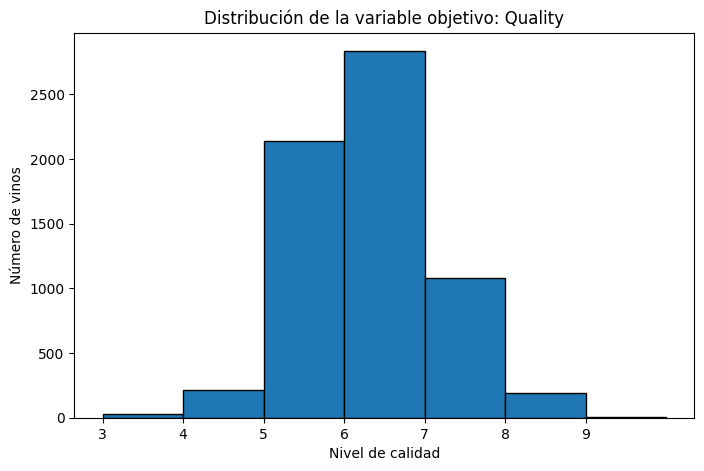

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Dimensión del dataset (número de observaciones y variables)
print("Dimensión de X:", X.shape)
print("Dimensión de y:", y.shape)

# Comprobar tipos de variables
print("\nTipos de variables:")
print(X.dtypes)

# Comprobar valores faltantes
print("\nValores faltantes en X:")
print(X.isnull().sum())

print("\nValores faltantes en y:")
print(y.isnull().sum())

# Estadística descriptiva
print("\nEstadística descriptiva:")
display(X.describe())

# Convertir 'y' a vector 1D
y_vector = y.values.ravel()

# Contar frecuencia de cada nivel de calidad
quality_counts = pd.Series(y_vector).value_counts().sort_index()
print("\nFrecuencia por nivel de quality:")
print(quality_counts)

# Histograma de la variable objetivo
plt.figure(figsize=(8,5))
plt.hist(y_vector, bins=range(int(min(y_vector)), int(max(y_vector)) + 2), edgecolor='black')

plt.title("Distribución de la variable objetivo: Quality")
plt.xlabel("Nivel de calidad")
plt.ylabel("Número de vinos")

plt.xticks(range(int(min(y_vector)), int(max(y_vector)) + 1))
plt.show()


**Interpretación histograma**:

El histograma muestra cuántos vinos hay de cada nivel de calidad en el dataset. Cada muestra del dataset corresponde a un vino individual con sus características químicas. Se observa que **la mayor parte de las muestras se concentran en las calidades 5, 6 y 7**, siendo 6 el valor más frecuente, mientras que las calidades extremas aparecen con menor frecuencia.

### 2.1 Matriz de correlación


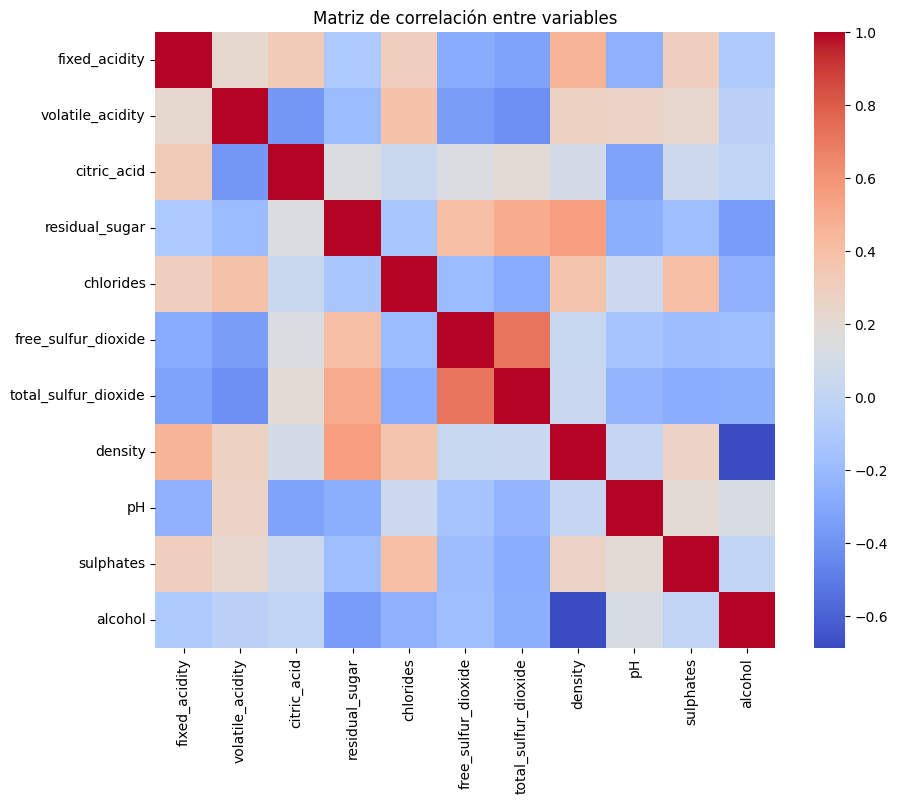

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(X.corr(), cmap="coolwarm", annot=False)
plt.title("Matriz de correlación entre variables")
plt.show()

**Interpretación de la matriz de correlación**

La matriz de correlación muestra algunas relaciones destacables entre las variables del conjunto de datos. En particular, se observa una correlación positiva fuerte entre free_sulfur_dioxide y total_sulfur_dioxide, lo cual es lógico ya que el dióxido de azufre total incluye el dióxido de azufre libre presente en el vino.

Asimismo, se aprecia una correlación negativa notable entre alcohol y density, lo que indica que a mayor contenido de alcohol la densidad del vino tiende a disminuir. Esto es coherente desde un punto de vista químico, ya que el alcohol es menos denso que el agua.

### 2.2 Relación entre variables y la calidad (quality)

In [ ]:
import pandas as pd

data = X.copy()
data["quality"] = y_vector

corr_quality = data.corr(numeric_only=True)["quality"].sort_values(ascending=False)

print("Correlación de cada variable con quality (ordenado):")
print(corr_quality)

print("\nTop 5 variables más correlacionadas con quality:")
print(corr_quality.drop("quality").head(5))

Correlación de cada variable con quality (ordenado):
quality                 1.000000
alcohol                 0.444319
citric_acid             0.085532
free_sulfur_dioxide     0.055463
sulphates               0.038485
pH                      0.019506
residual_sugar         -0.036980
total_sulfur_dioxide   -0.041385
fixed_acidity          -0.076743
chlorides              -0.200666
volatile_acidity       -0.265699
density                -0.305858
Name: quality, dtype: float64

Top 5 variables más correlacionadas con quality:
alcohol                0.444319
citric_acid            0.085532
free_sulfur_dioxide    0.055463
sulphates              0.038485
pH                     0.019506
Name: quality, dtype: float64


Variable más correlacionada con quality: alcohol


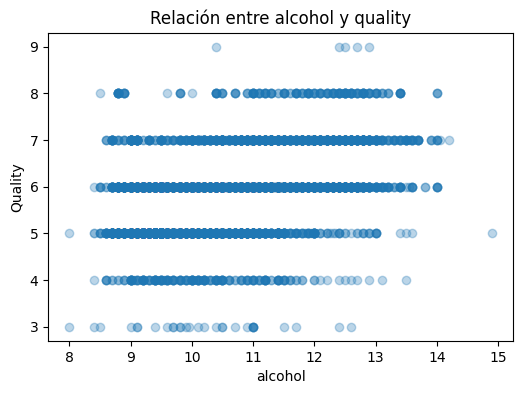

In [ ]:
# Seleccionar automáticamente la variable más correlacionada
top_feature = corr_quality.drop("quality").index[0]
print("Variable más correlacionada con quality:", top_feature)

# Representación gráfica de la relación
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(X[top_feature], y_vector, alpha=0.3)
plt.xlabel(top_feature)
plt.ylabel("Quality")
plt.title(f"Relación entre {top_feature} y quality")
plt.show()

**Interpretación del gráfico de dispersión**

Este gráfico muestra **cómo cambia la calidad del vino según la cantidad de alcohol**. Cada punto representa un vino del dataset. En el eje horizontal aparece la cantidad de alcohol y en el eje vertical la puntuación de calidad.

Se puede observar que, en general, **los vinos con mayor contenido de alcohol tienden a presentar niveles de calidad más altos**. Sin embargo,** esta relación no es completamente clara, ya que se observan dos aspectos importantes:

1.  **Existen vinos con cantidades de alcohol bastante altas pero con niveles de calidad diferentes**, por lo que no se puede afirmar con total seguridad que exista una relación directamente proporcional entre el contenido de alcohol y la calidad del vino (es decir, que a mayor alcohol siempre corresponda una mayor calidad o viceversa).
2.   **La falta de muestras en los extremos** (tal como se ha estudiado en el histograma anterior) hace que sea extremadamente difícil afirmar que la cantidad de alcohol es una variable decisiva a la hora de determinar la calidad del vino.



### 2.3 Distribución de una variable según la calidad (boxplot)

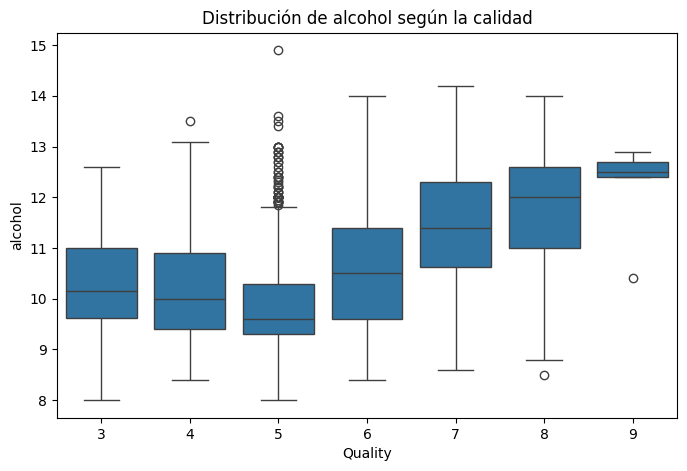

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x=y_vector, y=X[top_feature])
plt.xlabel("Quality")
plt.ylabel(top_feature)
plt.title(f"Distribución de {top_feature} según la calidad")
plt.show()

**Interpretación del boxplot**

Este gráfico muestra cómo cambia la cantidad de alcohol en función de la calidad del vino. En el eje horizontal aparecen los distintos niveles de calidad del vino, mientras que en el eje vertical se representa la cantidad de alcohol.

Cada caja representa cómo se distribuyen los valores de alcohol para un nivel concreto de calidad. La línea que aparece dentro de cada caja indica el valor central (la mediana), mientras que el tamaño de la caja muestra la variabilidad de los valores de alcohol dentro de ese grupo de vinos.

En general, se puede observar que **a medida que aumenta la calidad del vino, la cantidad de alcohol tiende a ser mayor**. Por ejemplo, los vinos con calidades más altas, como 7, 8 o 9, suelen presentar niveles de alcohol más elevados que los vinos con calidades más bajas.

Sin embargo, se observa **cierta variabilidad en los valores de alcohol dentro de cada nivel de calidad**. **Esto indica que vinos con la misma puntuación pueden tener cantidades de alcohol diferentes.** También aparecen algunos puntos aislados fuera de las cajas, que representan valores poco comunes de alcohol para ese nivel de calidad.

## 3. Preparación de los Datos
Para evaluar correctamente los modelos, el conjunto de datos se divide en entrenamiento y prueba.
El conjunto de entrenamiento se utiliza para ajustar el modelo, mientras que el conjunto de prueba permite evaluar su capacidad de generalización sobre datos no vistos previamente.

In [ ]:
from sklearn.model_selection import train_test_split

# Convertir y a vector 1D
y = y.values.ravel()

# División 80% entrenamiento - 20% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Tamaño entrenamiento:", X_train.shape)
print("Tamaño prueba:", X_test.shape)

Tamaño entrenamiento: (5197, 11)
Tamaño prueba: (1300, 11)


## 4. Modelo de clasificación

### 4.1 Validación cruzada

Además de la partición entrenamiento/prueba, se emplea validación cruzada para
obtener una estimación más robusta del rendimiento de los modelos.

Este procedimiento divide los datos en varios subconjuntos y entrena el modelo
varias veces, evitando que los resultados dependan de una única partición.

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV

# Validación cruzada en train
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Gaussian Naive Bayes
nb_model = GaussianNB()
nb_cv_scores = cross_val_score(nb_model, X_train, y_train, cv=cv, scoring="accuracy")
nb_mean = nb_cv_scores.mean()
nb_std = nb_cv_scores.std()

# KNN + escalado
knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])
knn_cv_scores = cross_val_score(knn_model, X_train, y_train, cv=cv, scoring="accuracy")
knn_mean = knn_cv_scores.mean()
knn_std = knn_cv_scores.std()

# Random Forest + GridSearchCV
rf_param_grid = {
    "n_estimators": [200, 500],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
}

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

rf_grid = GridSearchCV(
    estimator=rf_base,
    param_grid=rf_param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_
rf_best_mean = rf_grid.best_score_
rf_best_params = rf_grid.best_params_
rf_best_std = rf_grid.cv_results_["std_test_score"][rf_grid.best_index_]

# SVM + escalado + GridSearchCV
svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC())
])

svm_param_grid = {
    "svm__C": [0.1, 1, 10],
    "svm__kernel": ["linear", "rbf"],
    "svm__gamma": ["scale", "auto"]
}

svm_grid = GridSearchCV(
    estimator=svm_model,
    param_grid=svm_param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

svm_grid.fit(X_train, y_train)

best_svm = svm_grid.best_estimator_
svm_best_mean = svm_grid.best_score_
svm_best_params = svm_grid.best_params_
svm_best_std = svm_grid.cv_results_["std_test_score"][svm_grid.best_index_]

# Mostrar resultados de CV
print(f"Naive Bayes CV Accuracy (train): {nb_mean:.3f} ± {nb_std:.3f}")
print(f"KNN + Scaler CV Accuracy (train): {knn_mean:.3f} ± {knn_std:.3f}")
print(f"RF (GridSearch) CV Accuracy (train): {rf_best_mean:.3f} ± {rf_best_std:.3f} (mejores params: {rf_best_params})")
print(f"SVM (GridSearch) CV Accuracy (train): {svm_best_mean:.3f} ± {svm_best_std:.3f} (mejores params: {svm_best_params})")

# Elegir mejor modelo por accuracy media
clf_scores = {
    "Naive Bayes": nb_mean,
    "KNN + Scaler": knn_mean,
    "Random Forest (GridSearch)": rf_best_mean,
    "SVM (GridSearch)": svm_best_mean
}

clf_models = {
    "Naive Bayes": nb_model,
    "KNN + Scaler": knn_model,
    "Random Forest (GridSearch)": best_rf,
    "SVM (GridSearch)": best_svm
}

best_clf_name = max(clf_scores, key=clf_scores.get)
final_model = clf_models[best_clf_name]

print("\nModelo de clasificación seleccionado tras validación cruzada:", best_clf_name)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Naive Bayes CV Accuracy (train): 0.457 ± 0.013
KNN + Scaler CV Accuracy (train): 0.547 ± 0.020
RF (GridSearch) CV Accuracy (train): 0.667 ± 0.012 (mejores params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 500})
SVM (GridSearch) CV Accuracy (train): 0.584 ± 0.012 (mejores params: {'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'})

Modelo de clasificación seleccionado tras validación cruzada: Random Forest (GridSearch)


**Interpretación validación cruzada (clasificación)**

En los resultados del entrenamiento mediante validación cruzada se muestran tanto la media como la desviación típica de la métrica *accuracy*.

* **Media:** representa el promedio de los valores de *accuracy* obtenidos en cada uno de los *folds* de la validación cruzada.
* **Desviación típica:** indica la variabilidad entre los distintos valores de *accuracy* obtenidos en los *folds*. Permite evaluar la estabilidad del modelo, es decir, si su rendimiento se mantiene consistente entre las diferentes particiones de los datos.

Observando los valores obtenidos, se puede apreciar que el modelo con mejor rendimiento es **Random Forest**, ya que presenta la media más alta (**0.667**). Esto significa que, en promedio, el modelo ha acertado el **66,7 % de las predicciones** durante la validación cruzada.

Además, este modelo presenta una **desviación típica muy baja (0.012)**. Al ser un valor cercano a 0, indica que el rendimiento del modelo ha sido **muy estable entre los distintos folds**, lo que sugiere una buena consistencia en sus predicciones.



### 4.2 Selección modelo de clasificación

Se va a proceder a entrenar con el conjunto TRAIN el Random Forest Classifier con mejor configuración en validación cruzada.


In [ ]:
from sklearn.ensemble import RandomForestClassifier

final_model.fit(X_train, y_train)

print("\nModelo final de clasificación entrenado correctamente.")
print(final_model)
print("Número de características utilizadas:", X_train.shape[1])
print("Número de muestras de entrenamiento:", X_train.shape[0])




Modelo final de clasificación entrenado correctamente.
RandomForestClassifier(min_samples_split=5, n_estimators=500, n_jobs=-1,
                       random_state=42)
Número de características utilizadas: 11
Número de muestras de entrenamiento: 5197


### 4.3 Evaluación del modelo de clasificación

Una vez entrenado el modelo Random Forest, se procede a evaluar su rendimiento utilizando el conjunto TEST, es decir, datos que el modelo no ha visto durante el entrenamiento.

Para evaluar los resultados se va a utilizar:

*   **Matriz de confusión:** tabla que permite comparar las clases reales (valores verdaderos del dataset) y las clases predichas por el modelo. Cada fila representa la clase real y cada columna la clase predicha por el modelo.
*   **F1 score:** métrica permite obtener una media equilibrada del rendimiento del modelo teniendo en cuenta dos métricas: Precision y Recall. Su valor está comprendido entre 0 (rendimiento muy malo) y 1 (rendimiento excelente).










Confusion Matrix:
[[  0   0   2   4   0   0   0]
 [  1   3  26  13   0   0   0]
 [  0   1 292 105   4   0   0]
 [  0   0 110 458  29   0   0]
 [  0   0   3  96 115   1   0]
 [  0   0   0  13  11  12   0]
 [  0   0   0   1   0   0   0]]

F1-score (weighted): 0.6626192126475424

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       0.75      0.07      0.13        43
           5       0.67      0.73      0.70       402
           6       0.66      0.77      0.71       597
           7       0.72      0.53      0.61       215
           8       0.92      0.33      0.49        36
           9       0.00      0.00      0.00         1

    accuracy                           0.68      1300
   macro avg       0.53      0.35      0.38      1300
weighted avg       0.68      0.68      0.66      1300



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


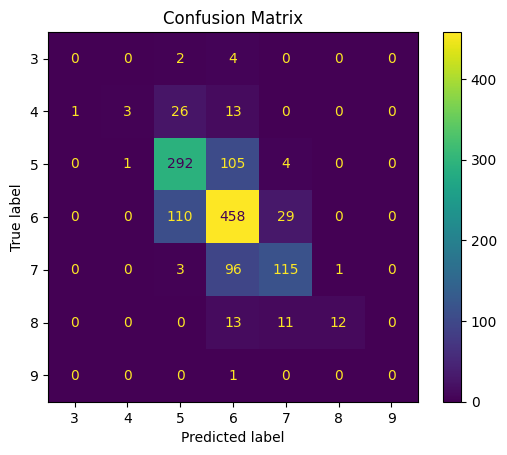

In [ ]:
from sklearn.metrics import confusion_matrix, f1_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

labels = [3, 4, 5, 6, 7, 8, 9]

y_pred = final_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred, labels=labels)

print("Confusion Matrix:")
print(cm)

f1 = f1_score(y_test, y_pred, average="weighted")
print("\nF1-score (weighted):", f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, labels=labels))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot()

plt.title("Confusion Matrix")
plt.show()

**Interpretación evaluación modelo (clasificación)**

Los resultados obtenidos tras la evaluación del modelo muestran un rendimiento global aceptable.

En primer lugar, la **matriz de confusión** permite observar cuántas muestras han sido clasificadas correctamente en cada categoría de calidad. En este caso, el modelo ha identificado correctamente:

- 3 muestras de calidad **4**
- 292 muestras de calidad **5**
- 458 muestras de calidad **6**
- 115 muestras de calidad **7**
- 13 muestras de calidad **8**

Estos resultados muestran que el modelo funciona mejor en las clases más frecuentes del conjunto de datos, especialmente en las calidades **5 y 6**, que son también las más representadas en el dataset.

Por otro lado, el **F1-score ponderado (weighted)** obtenido es **0.662**. Esta métrica combina **precision** y **recall** en un único valor y además tiene en cuenta el número de ejemplos de cada clase.  

- La **precision** indica cuántas veces el modelo acertó una clase que predijo como correcta.
- El **recall** evalúa el número de muestras encontradas de una determinada calidad con respecto al total de muestras existentes de esa calidad.

Por ejemplo, si el modelo predice que un vino tiene **calidad 5**, la *precision* mide cuántas veces esa predicción es correcta. En cambio, el *recall* mide cuántos de todos los vinos que realmente eran de calidad 5 han sido detectados por el modelo.

El valor de **F1-score = 0.662** indica que, en general, el modelo mantiene un **equilibrio razonable entre precision y recall**, ofreciendo un rendimiento global moderado al considerar todas las clases del problema.

Por último, la métrica **support** indica el número de muestras reales que existen en el conjunto de datos para cada clase de calidad. Esta información es importante porque permite entender el peso que tiene cada clase en la evaluación del modelo. Por ejemplo, si una clase tiene pocas muestras (como ocurre con algunas calidades menos frecuentes), el modelo dispone de menos información para aprender a identificarlas correctamente, lo que puede afectar a su rendimiento en esas categorías.




 ## 5. Modelo de regresión
 Se va a proceder a entrenar con el conjunto TRAIN el Random Forest Regressor con mejor configuración en validación cruzada.


### 5.1 Validación cruzada

Además de la partición entrenamiento/prueba, se emplea validación cruzada para
obtener una estimación más robusta del rendimiento de los modelos.

Este procedimiento divide los datos en varios subconjuntos y entrena el modelo
varias veces, evitando que los resultados dependan de una única partición.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import KFold, cross_val_score, GridSearchCV

# Validación cruzada en TRAIN
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Linear Regression
lr_model = LinearRegression()
lr_cv_scores = cross_val_score(lr_model, X_train, y_train, cv=cv, scoring="neg_mean_squared_error")
lr_mse_scores = -lr_cv_scores
lr_mean = lr_mse_scores.mean()
lr_std = lr_mse_scores.std()

# KNN Regressor + escalado
knn_reg_model = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsRegressor(n_neighbors=5))
])
knn_reg_cv_scores = cross_val_score(knn_reg_model, X_train, y_train, cv=cv, scoring="neg_mean_squared_error")
knn_reg_mse_scores = -knn_reg_cv_scores
knn_reg_mean = knn_reg_mse_scores.mean()
knn_reg_std = knn_reg_mse_scores.std()

# Random Forest Regressor + GridSearchCV
rf_reg_param_grid = {
    "n_estimators": [200, 500],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
}

rf_reg_base = RandomForestRegressor(random_state=42, n_jobs=-1)

rf_reg_grid = GridSearchCV(
    estimator=rf_reg_base,
    param_grid=rf_reg_param_grid,
    cv=cv,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

rf_reg_grid.fit(X_train, y_train)

best_rf_reg = rf_reg_grid.best_estimator_
rf_reg_best_mean = -rf_reg_grid.best_score_
rf_reg_best_params = rf_reg_grid.best_params_
rf_reg_best_std = rf_reg_grid.cv_results_["std_test_score"][rf_reg_grid.best_index_]

# SVR + escalado + GridSearchCV
svr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR())
])

svr_param_grid = {
    "svr__C": [0.1, 1, 10],
    "svr__kernel": ["linear", "rbf"],
    "svr__gamma": ["scale", "auto"]
}

svr_grid = GridSearchCV(
    estimator=svr_model,
    param_grid=svr_param_grid,
    cv=cv,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

svr_grid.fit(X_train, y_train)

best_svr = svr_grid.best_estimator_
svr_best_mean = -svr_grid.best_score_
svr_best_params = svr_grid.best_params_
svr_best_std = svr_grid.cv_results_["std_test_score"][svr_grid.best_index_]

# Mostrar resultados de CV
print(f"Linear Regression CV MSE (train): {lr_mean:.3f} ± {lr_std:.3f}")
print(f"KNN Regressor CV MSE (train): {knn_reg_mean:.3f} ± {knn_reg_std:.3f}")
print(f"RF Regressor (GridSearch) CV MSE (train): {rf_reg_best_mean:.3f} ± {rf_reg_best_std:.3f} (mejores params: {rf_reg_best_params})")
print(f"SVR (GridSearch) CV MSE (train): {svr_best_mean:.3f} ± {svr_best_std:.3f} (mejores params: {svr_best_params})")

# Elegir mejor modelo por menor MSE medio
reg_scores = {
    "Linear Regression": lr_mean,
    "KNN Regressor": knn_reg_mean,
    "Random Forest Regressor (GridSearch)": rf_reg_best_mean,
    "SVR (GridSearch)": svr_best_mean
}

reg_models = {
    "Linear Regression": lr_model,
    "KNN Regressor": knn_reg_model,
    "Random Forest Regressor (GridSearch)": best_rf_reg,
    "SVR (GridSearch)": best_svr
}

best_reg_name = min(reg_scores, key=reg_scores.get)
final_reg_model = reg_models[best_reg_name]

print("\nModelo de regresión seleccionado tras validación cruzada:", best_reg_name)

Linear Regression CV MSE (train): 0.543 ± 0.026
KNN Regressor CV MSE (train): 0.506 ± 0.035
RF Regressor (GridSearch) CV MSE (train): 0.390 ± 0.033 (mejores params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500})
SVR (GridSearch) CV MSE (train): 0.469 ± 0.027 (mejores params: {'svr__C': 1, 'svr__gamma': 'scale', 'svr__kernel': 'rbf'})

Modelo de regresión seleccionado tras validación cruzada: Random Forest Regressor (GridSearch)


**Interpretación validación cruzada (regresión)**

Observando los resultados obtenidos tras evaluar los diferentes modelos de regresión mediante validación cruzada, se puede concluir que el modelo con mejor rendimiento es **Random Forest Regressor**, ya que presenta el **menor valor de MSE (0.390)**. Esto indica que, en promedio, es el modelo que comete menor error cuadrático en sus predicciones.

Además, presenta una **desviación típica de 0.033**, lo que indica que el valor del MSE se mantiene relativamente estable entre los distintos *folds* de la validación cruzada.

Cabe destacar que el modelo **Linear Regression** es el que presenta la **menor desviación típica (0.026)**, lo que sugiere que su rendimiento es ligeramente más estable entre los diferentes *folds*. Sin embargo, su **MSE medio es considerablemente mayor (0.543)**, por lo que su rendimiento global es inferior al obtenido por el modelo Random Forest.

Por este motivo, el modelo **Random Forest Regressor** ha sido seleccionado como modelo final tras el proceso de validación cruzada.

### 5.2 Selección modelo de regresión


In [ ]:
final_reg_model.fit(X_train, y_train)

print("\nModelo final de regresión entrenado correctamente.")
print(final_reg_model)
print("Número de características utilizadas:", X_train.shape[1])
print("Número de muestras de entrenamiento:", X_train.shape[0])


Modelo final de regresión entrenado correctamente.
RandomForestRegressor(n_estimators=500, n_jobs=-1, random_state=42)
Número de características utilizadas: 11
Número de muestras de entrenamiento: 5197


### 5.3 Evaluación modelo de regresión
Una vez entrenado el modelo **Random Forest Regressor**, se procede a evaluar su rendimiento utilizando el conjunto **TEST**, es decir, datos que el modelo no ha visto durante el entrenamiento.

Para evaluar los resultados se va a utilizar:

* **Mean Absolute Error (MAE):** mide el error medio absoluto entre los valores reales y los valores predichos por el modelo. Indica, en promedio, **cuánto se equivoca el modelo en sus predicciones**. Cuanto más cercano a **0**, mejor es el modelo.

* **Mean Squared Error (MSE):** mide el error medio cuadrático entre los valores reales y los valores predichos. En este caso, los errores se elevan al cuadrado, por lo que **los errores grandes tienen más peso**. Al igual que en el MAE, valores más cercanos a **0** indican un mejor rendimiento del modelo.

* **R² score (coeficiente de determinación):** mide **qué tan bien el modelo explica la variabilidad de los datos**. Su valor está comprendido entre **0 y 1**, donde valores cercanos a **1** indican que el modelo explica bien los datos, mientras que valores cercanos a **0** indican que el modelo tiene poca capacidad predictiva.

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Predicción final en TEST
y_pred_reg = final_reg_model.predict(X_test)

# Métricas de evaluación
mae = mean_absolute_error(y_test, y_pred_reg)
mse = mean_squared_error(y_test, y_pred_reg)
r2 = r2_score(y_test, y_pred_reg)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("R² score:", r2)

Mean Absolute Error (MAE): 0.43598
Mean Squared Error (MSE): 0.36882577538461536
R² score: 0.5006060515453346


**Interpretación evaluación modelo de regresión**

Observando los resultados obtenidos en esta evaluación, se pueden extraer las siguientes conclusiones:

* Se ha obtenido un **MAE (Mean Absolute Error) de 0.436**, lo que indica que el modelo comete un error medio aproximado de **0.44 puntos** entre el valor predicho y el valor real.

* El **MSE (Mean Squared Error) es de 0.369**, un valor relativamente bajo y cercano a 0, lo que sugiere que el modelo no comete errores grandes con frecuencia en sus predicciones.

* El **coeficiente de determinación R² es 0.500**, lo que indica que el modelo es capaz de **explicar aproximadamente el 50 % de la variabilidad de los datos**, mejorando claramente el rendimiento de un modelo simple que predijera siempre el valor medio.




## 6. Comparación entre ambos modelos

Una vez entrenados y evaluados los modelos de **clasificación** y **regresión**, se procede a realizar una comparación entre ambos con el objetivo de analizar su rendimiento y su capacidad predictiva.

Para ello se utilizan las métricas calculadas previamente en cada modelo. En el caso del **modelo de clasificación (Random Forest Classifier)** se han utilizado métricas como la **matriz de confusión** y el **F1-score**, que permiten evaluar la capacidad del modelo para predecir correctamente las distintas clases de calidad del vino.

Por otro lado, el **modelo de regresión (Random Forest Regressor)** se ha evaluado utilizando métricas propias de problemas de regresión, como **Mean Absolute Error (MAE)**, **Mean Squared Error (MSE)** y el **coeficiente de determinación R²**, que permiten medir el nivel de error de las predicciones y la capacidad del modelo para explicar la variabilidad de los datos.

A continuación, se presentan los resultados obtenidos por ambos modelos con el fin de analizar sus diferencias y determinar cuál de los enfoques resulta más adecuado para el problema de predicción de la calidad del vino.

In [ ]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Tipo": ["Clasificación", "Regresión"],
    "Modelo": [best_clf_name, best_reg_name],
    "Métrica principal": ["F1-score (weighted)", "MAE"],
    "Valor métrica principal": [f1, mae],
    "Otras métricas": [
        "-",
        f"MSE: {mse:.3f} | R²: {r2:.3f}"
    ]
})

display(comparison_df)


,Tipo,Modelo,Métrica principal,Valor métrica principal,Otras métricas
0,Clasificación,Random Forest (GridSearch),F1-score (weighted),0.662619,-
1,Regresión,Random Forest Regressor (GridSearch),MAE,0.435980,MSE: 0.369 | R²: 0.501


**Interpretación comparación modelos**

A partir de los resultados obtenidos, se observa que en ambos enfoques el algoritmo **Random Forest**, optimizado mediante **GridSearch**, muestra un comportamiento sólido.

En el caso del problema de **clasificación**, el modelo obtiene un **F1-score (weighted) de 0.663**, lo que indica un equilibrio razonable entre *precision* y *recall* al clasificar las distintas calidades del vino. Este valor sugiere que el modelo es capaz de capturar parcialmente los patrones presentes en los datos, aunque todavía existe margen de mejora.

Por otro lado, en el problema de **regresión**, el modelo **Random Forest Regressor** obtiene un **MAE de 0.436**, un **MSE de 0.369** y un **R² de 0.501**. Esto implica que el error medio al predecir la calidad es de aproximadamente **0.44 puntos**, y que el modelo es capaz de explicar cerca del **50 % de la variabilidad de los datos**.

Cabe destacar que la **comparación directa entre ambos enfoques no es completamente equivalente**, ya que se trata de problemas distintos. En **clasificación**, métricas como el *F1-score* buscan maximizar la capacidad del modelo para clasificar correctamente las observaciones, mientras que en **regresión** métricas como *MAE* o *MSE* evalúan el error de las predicciones (por lo que valores más bajos indican mejor rendimiento). Por este motivo, cada modelo debe evaluarse dentro de su propio contexto.

Se puede llegar a la conclusión de que en conjunto los resultados indican que **Random Forest es un algoritmo adecuado para este dataset**, ya que su naturaleza basada en múltiples árboles de decisión permite capturar **relaciones no lineales y combinaciones complejas entre variables**. No obstante, el rendimiento moderado puede explicarse en parte por la **naturaleza subjetiva de la variable calidad del vino**, que depende de evaluaciones humanas y puede introducir cierta variabilidad difícil de modelar.